# Astronomy Application

In [2]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
from geomstats.geometry.hypersphere import Hypersphere
import geomstats.visualization as visualization

INFO: Using numpy backend


In [3]:
plt.rcParams.update({'font.size': 10,
                     'mathtext.fontset': 'stix',
                     'font.family': 'serif',
                     'font.serif':'Palatino'})

## Setting up

In [4]:
df = pd.read_csv('BATSE_4B.txt', header=None, delim_whitespace=True, encoding='utf-8')

In [5]:
sphere = Hypersphere(dim=2)

X_sph = df[[5, 6]].values * np.pi/180.
X = sphere.spherical_to_extrinsic(X_sph)

In [6]:
sigma2 = np.mean(np.power(df[9].values * np.pi/180.,2))
sigma2

0.009240724037789944

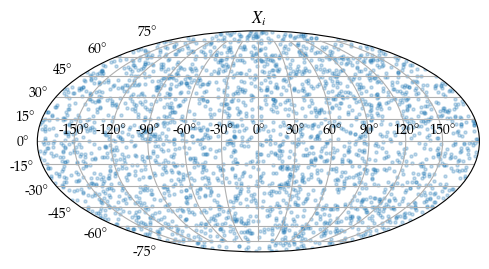

In [9]:
fig = plt.figure(figsize=(5,4))
ax = fig.add_subplot(111, projection='mollweide')

ax.grid(True)
ax.set_title('$X_i$')
ax.scatter(X_sph[:,0]-np.pi, X_sph[:,1], color='C0', s=5, alpha=0.25)

plt.tight_layout()
# plt.savefig('figs/astro_with_grid.pdf')
# plt.savefig('figs/astro_with_grid.png')
plt.savefig('astro_data.pdf')

## Density estimation

In [7]:
def density_estimate(x_lon, x_lat, M):
    out = np.zeros(shape=x_lon.shape, dtype='complex128')
    theta = x_lat
    phi = x_lon
    for i in range(X.shape[0]):
        for m in range(M):
            p_m = sp.special.legendre(m)
            dot = np.sin(theta)*np.cos(phi)*X[i,0] + np.sin(theta)*np.sin(phi)*X[i,1]+np.cos(phi)*X[i,2]
            out += (2*m+1)*p_m(dot)/(4*np.pi)        
    return np.real(out)/X.shape[0]

In [32]:
M = 4
res_lon = 40
res_lat = 60

x_lon = np.linspace(-np.pi, np.pi, res_lon)
x_lat = np.linspace(-np.pi/2, np.pi/2, res_lat)
x_lon_, x_lat_ = np.meshgrid(x_lon, x_lat)

hat_f = density_estimate(x_lon_, x_lat_, M)

Text(0.5, 1.0, '$\\hat{f}(\\cdot)$')

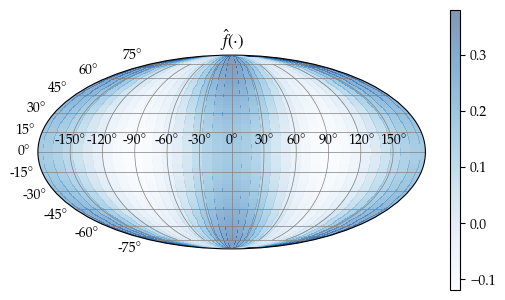

In [33]:
fig = plt.figure(figsize=(5,4))
ax = fig.add_subplot(111, projection='mollweide')

im = ax.pcolormesh(
    x_lon_,
    x_lat_,
    hat_f,
    alpha=0.5,
    shading='auto',
    cmap='Blues'
)

ax.grid(True, color='gray', lw=0.5)
cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.7])
fig.colorbar(im, orientation='vertical', cax=cbar_ax)
ax.set_title('$\\hat{f}(\cdot)$')

## Empirical Bayes denoising

In [34]:
def denoiser(x_lon, x_lat, M, rho):
    
    # estimate f
    hat_f = density_estimate(x_lon, x_lat, M)
    
    # estimate grad f
    hat_grad_f = np.zeros(shape=(x_lon.shape[0],3),dtype='complex128')
    theta = x_lat
    phi = x_lon
    for i in range(X.shape[0]):
        for m in range(1,M):
            p_m_deriv = sp.special.legendre(m).deriv()
            dot = np.sin(theta)*np.cos(phi)*X[i,0] + np.sin(theta)*np.sin(phi)*X[i,1]+np.cos(theta)*X[i,2]
            hat_grad_f += (2*m+1)*p_m_deriv(dot).reshape(-1,1) @ X[i,:].reshape(1,-1)/(4*np.pi)
    hat_grad_f = np.real(hat_grad_f)/X.shape[0]
           
    # compute score function
    hat_score = hat_grad_f / np.maximum(hat_f, rho).reshape(-1,1)

    # compute denoiser
    delta = np.zeros((x_lon.shape[0],3))
    x = sphere.spherical_to_extrinsic(np.dstack((x_lon, x_lat)).reshape(-1, 2))
    for j in range(x_lon.shape[0]):
        x_ = x[j,:].reshape(-1,1)
        v = x[j,:] + (np.eye(3) - x_@ x_.T)@hat_score[j,:]
        delta[j,:] = sphere.metric.exp(sigma2*v, X[j,:])
    
    return delta

In [35]:
rho = 0.1
delta = denoiser(X_sph[:,0], X_sph[:,1], M, rho)
delta_sph = sphere.extrinsic_to_spherical(delta)

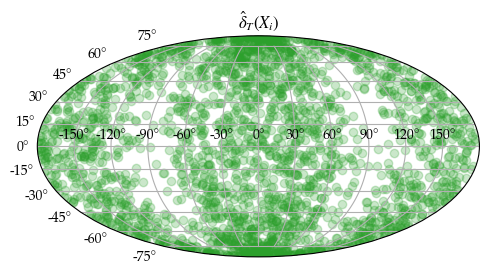

In [36]:
fig = plt.figure(figsize=(5,4))
ax = fig.add_subplot(111, projection='mollweide')

ax.grid(True)
ax.set_title('$\\hat{\\delta}_T(X_i)$')
ax.scatter(delta_sph[:,1]-np.pi, delta_sph[:,0]-np.pi/2, color='C2', alpha=0.25)

plt.tight_layout()

## Plotting

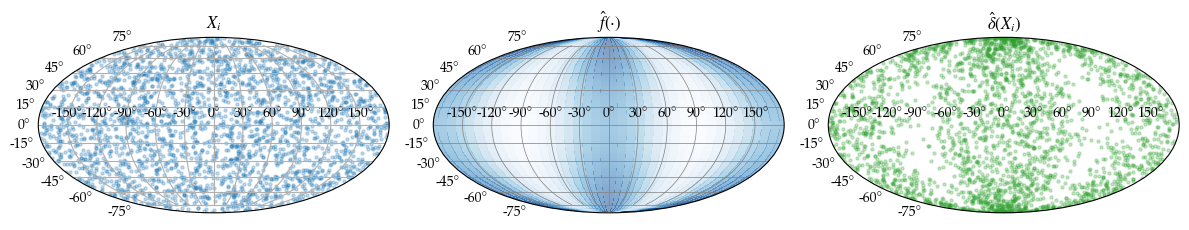

In [37]:
fig = plt.figure(figsize=(12,4))
ax = [None] * 3

ax[0] = fig.add_subplot(131, projection='mollweide')
ax[0].grid(True)
ax[0].set_title('$X_i$')
ax[0].scatter(X_sph[:,0] - np.pi, X_sph[:,1], color='C0', s=5, alpha=0.25)

ax[1] = fig.add_subplot(132, projection='mollweide')
im = ax[1].pcolormesh(
    x_lon_,
    x_lat_,
    hat_f,
    alpha=0.5,
    shading='auto',
    cmap='Blues'
)
ax[1].grid(True, color='gray', lw=0.5)
ax[1].set_title('$\\hat{f}(\cdot)$')

ax[2] = fig.add_subplot(133, projection='mollweide')
ax[2].scatter(delta_sph[:,1]-np.pi, delta_sph[:,0]-np.pi/2, color='C2', s=5, alpha=0.25)
ax[2].set_title('$\\hat{\\delta}(X_i)$')

plt.tight_layout()

plt.savefig('astro.pdf')